## Weather data

Most crop simulations require weather input data. Most commonly:
    - Solar irradiance (MJ/m2/day)
    - Precipation (mm/month)
    
And less important
    - Days with rain (1/month)
    
This demo comes with weather data files which can be found in the inputs folder.
    
**Note, these input files can for instance be opened/altered in Excel.**

In [1]:
# import pandas --- spreadsheet library
import pandas as pd

# import matplotlib --- plotting library
import matplotlib.pyplot as plt 

# read-in the csv-file
weather_data = pd.read_csv('./input/bangladesh.csv',index_col='Date')
weather_data.index = pd.to_datetime(weather_data.index, errors='coerce')

#### Note the quite variable solar radiation

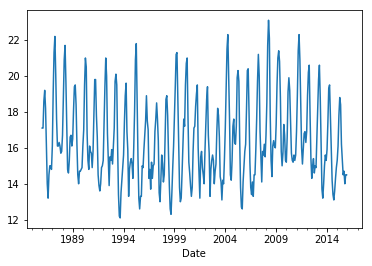

In [2]:
weather_data['Solar (MJ/m2)'].plot()

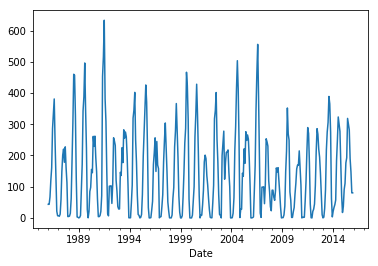

In [3]:
weather_data['Precip (mm)'].plot()

In [4]:
import sys
sys.path.append('../PalmSim')
sys.path.append('..')
from palmsim import PalmField

year_of_planting = weather_data.index.year[0]

# 1. Initialize the model
p = PalmField(year_of_planting=year_of_planting)

# 2. Couple the solar radiation data:
p.weather.radiation_series = weather_data['Solar (MJ/m2)'].resample('D').pad()

s = weather_data['Precip (mm)'].resample('D').pad()
s = s/s.index.days_in_month

p.weather.rainfall_series = s

In [5]:
p.weather

Object: Weather

Property                                     Value Unit        
--------------------------------------------------------------
PAR                                         8.2521  MJ/m**2/day 
PAR_monthly                                 2.4756  TJ/ha/mo    
radiation                                  16.5042  MJ/m**2/day 
radiation_monthly                           4.9513  TJ/ha/mo    
radiation_series_mean                      16.5042  MJ/m**2/day 
raindays                                   14.0000  1/mo        
raindays_series_mean                       14.0000  1/mo        
rainfall                                    4.7270  mm/mo       
rainfall_series_mean                        4.7270  mm/mo       

In [6]:
p.date_tuple

(1986, 1, 1)

In [7]:
p.trunk

Object: Trunk

Property                                     Value Unit        
--------------------------------------------------------------
assim_growth                                0.0002  t_CH2O/ha/day
maintenance_requirement                     0.0001  t_CH2O/ha/day
mass                                        0.2760  t_DM/ha     
mass_change_rate                            0.0001  t_DM/ha/day 
mass_change_rate_per_palm                   0.0009  kg_DM/palm/day
mass_growth_rate                            0.0001  t_DM/ha/day 
mass_loss_rate                              0.0000  t_DM/ha/day 
mass_per_palm                               2.0000  kg_DM/palm  
potential_growth_rate                       0.0006  t_DM/ha/day 
potential_growth_rate_per_palm              0.0044  kg_DM/palm/day
potential_sink_strength                     0.0009  t_CH2O/ha/day

In [8]:
p.roots

Object: Roots

Property                                     Value Unit        
--------------------------------------------------------------
assim_growth                                0.0011  t_CH2O/ha/day
maintenance_requirement                     0.0012  t_CH2O/ha/day
mass                                        0.5520  t_DM/ha     
mass_change_rate                           -0.0013  t_DM/ha/day 
mass_growth_rate                            0.0008  t_DM/ha/day 
mass_loss_rate                              0.0020  t_DM/ha/day 
mass_per_palm                               4.0000  kg_DM/palm  
potential_growth_rate                       0.0037  t_DM/ha/day 
potential_growth_rate_per_palm              0.0271  kg_DM/ha/day
potential_sink_strength                     0.0054  t_CH2O/ha/day